In [1]:
# %pip install pandas geopandas shapely scipy

In [2]:
# 전국 인구데이터 파일 읽기
import pandas as pd
import glob
import os

# 1. 폴더 경로 설정
folder_path = "/content/drive/MyDrive/10km/txt_data"

# 2. txt 파일 리스트 불러오기(폴더 내 모든 txt)
file_list = glob.glob(os.path.join(folder_path, "*.txt"))

# 3. 모든 파일을 반복해서 읽고 리스트에 저장
dfs = []
for file in file_list:
    df = pd.read_csv(file, sep="^",header=None, names=['year','grid','code','value'])
    dfs.append(df)

# # 4. 모든 데이터 병합
df_all = pd.concat(dfs,ignore_index=True)

# 5. 고령 인구  코드 필터링 (65~99세)
df_old = df_all[df_all['code'].str.match(r"in_age_0(6[5-9]|9[0-9])")]

# 6. 격자(grid)별 고령 인구 합계 집계
df_old_sum = df_old.groupby('grid')['value'].sum().reset_index()
df_old_sum.columns = ['grid_id','elderly_population']

# # 7. 결과 저장 (csv)
# df_old_sum.to_csv("/content/drive/MyDrive/elderly_population_by")

In [3]:
df_old_sum

,grid_id,elderly_population
0,가다76,10
1,가다86,28
2,가라83,34
3,가라90,10
4,가사49,31
...,...,...
1224,마아01,37
1225,바사94,95
1226,바사95,105
1227,사사04,493


In [4]:
import geopandas as gpd
import glob
import os

# 폴더 경로 설정
folder_path = "/content/drive/MyDrive/10km/grid"

# grid_XXX_1K.shp 파일들 모두 가져오기
shp_list = glob.glob(os.path.join(folder_path, "grid_*_10K.shp"))

# 반복문으로 모든 shapefile 읽어오기
gdfs = []
for shp_file in shp_list:
    gdf_temp = gpd.read_file(shp_file)
    gdfs.append(gdf_temp)

# 모든 GeoDataFrame 병합
gdf_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

gdf_all.head()

,GRID_10K_C,geometry
0,바사94,"POLYGON ((1290000 1940000, 1290000 1950000, 13..."
1,바사95,"POLYGON ((1290000 1950000, 1290000 1960000, 13..."
2,나마60,"POLYGON ((860000 1700000, 860000 1710000, 8700..."
3,나마70,"POLYGON ((870000 1700000, 870000 1710000, 8800..."
4,나마80,"POLYGON ((880000 1700000, 880000 1710000, 8900..."


In [5]:
# 중심좌표 추가 (위도,경도)
gdf_all['lon'] = gdf_all.geometry.centroid.x
gdf_all['lat'] = gdf_all.geometry.centroid.y

In [6]:
gdf_all.columns

Index(['GRID_10K_C', 'geometry', 'lon', 'lat'], dtype='object')

In [7]:
gdf_all

,GRID_10K_C,geometry,lon,lat
0,바사94,"POLYGON ((1290000 1940000, 1290000 1950000, 13...",1295000.0,1945000.0
1,바사95,"POLYGON ((1290000 1950000, 1290000 1960000, 13...",1295000.0,1955000.0
2,나마60,"POLYGON ((860000 1700000, 860000 1710000, 8700...",865000.0,1705000.0
3,나마70,"POLYGON ((870000 1700000, 870000 1710000, 8800...",875000.0,1705000.0
4,나마80,"POLYGON ((880000 1700000, 880000 1710000, 8900...",885000.0,1705000.0
...,...,...,...,...
1349,라사99,"POLYGON ((1090000 1990000, 1090000 2000000, 11...",1095000.0,1995000.0
1350,가라90,"POLYGON ((790000 1600000, 790000 1610000, 8000...",795000.0,1605000.0
1351,가라91,"POLYGON ((790000 1610000, 790000 1620000, 8000...",795000.0,1615000.0
1352,가라83,"POLYGON ((780000 1630000, 780000 1640000, 7900...",785000.0,1635000.0


In [8]:
# 병합: 수요지(격자) + 고령인구
gdf_merged = gdf_all.merge(df_old_sum, how='left',left_on = 'GRID_10K_C',right_on="grid_id")

# NaN은 고령인구 0으로 간주
gdf_merged['elderly_population'] = gdf_merged['elderly_population'].fillna(0)

gdf_merged[["GRID_10K_C", "lon", "lat", "elderly_population"]].head()   # 투영좌표계인걸로 확인.


,GRID_10K_C,lon,lat,elderly_population
0,바사94,1295000.0,1945000.0,95.0
1,바사95,1295000.0,1955000.0,105.0
2,나마60,865000.0,1705000.0,10.0
3,나마70,875000.0,1705000.0,0.0
4,나마80,885000.0,1705000.0,0.0


In [9]:
gdf_merged.tail()

,GRID_10K_C,geometry,lon,lat,grid_id,elderly_population
1349,라사99,"POLYGON ((1090000 1990000, 1090000 2000000, 11...",1095000.0,1995000.0,라사99,15.0
1350,가라90,"POLYGON ((790000 1600000, 790000 1610000, 8000...",795000.0,1605000.0,가라90,10.0
1351,가라91,"POLYGON ((790000 1610000, 790000 1620000, 8000...",795000.0,1615000.0,NaN,0.0
1352,가라83,"POLYGON ((780000 1630000, 780000 1640000, 7900...",785000.0,1635000.0,가라83,34.0
1353,가라93,"POLYGON ((790000 1630000, 790000 1640000, 8000...",795000.0,1635000.0,NaN,0.0


In [10]:
gdf_merged = gdf_merged[["GRID_10K_C", "lon", "lat", "elderly_population"]]
gdf_merged.head()

,GRID_10K_C,lon,lat,elderly_population
0,바사94,1295000.0,1945000.0,95.0
1,바사95,1295000.0,1955000.0,105.0
2,나마60,865000.0,1705000.0,10.0
3,나마70,875000.0,1705000.0,0.0
4,나마80,885000.0,1705000.0,0.0


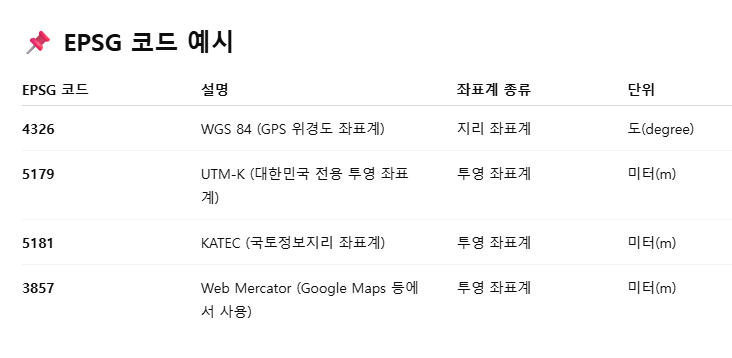

In [11]:
# UTM-K
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:5179","EPSG:4326",always_xy=True)  # 입력 5179 : 투영좌표계 -> 출력 4326 : 위도,경도 좌표계
gdf_merged[['lon', 'lat']] = gdf_merged.apply(lambda row: pd.Series(transformer.transform(row['lon'],row['lat'])),axis=1)
gdf_merged.head()

,GRID_10K_C,lon,lat,elderly_population
0,바사94,130.835080,37.457174,95.0
1,바사95,130.839090,37.547157,105.0
2,나마60,126.014615,35.331471,10.0
3,나마70,126.124614,35.332772,0.0
4,나마80,126.234620,35.333974,0.0


In [12]:
gdf_merged[:500]

,GRID_10K_C,lon,lat,elderly_population
0,바사94,130.835080,37.457174,95.0
1,바사95,130.839090,37.547157,105.0
2,나마60,126.014615,35.331471,10.0
3,나마70,126.124614,35.332772,0.0
4,나마80,126.234620,35.333974,0.0
...,...,...,...,...
495,마사11,128.796312,37.226759,657.0
496,마사21,128.909005,37.225471,405.0
497,마사31,129.021691,37.224077,1372.0
498,마사41,129.134368,37.222575,183.0


In [13]:
# 저장
gdf_merged.to_csv("gdf_merged.csv",index=False,encoding='utf-8-sig')

In [14]:
hospital_df = pd.read_csv("/content/drive/MyDrive/filtered_hospital.csv")
hospital_df

,요양기관명,종별코드명,총의사수,좌표(X),좌표(Y)
0,(VOM)봄안과의원,의원,3,128.691894,35.869852
1,(사) 경찰공제회 포항의원,의원,1,129.392904,35.942317
2,(사)경찰공제회남부의원,의원,1,126.708861,37.384910
3,(사)대한결핵협회경기도지부부설복십자의원,의원,1,127.008966,37.271984
4,(사)대한결핵협회부산광역시지부 복십자의원,의원,2,129.098875,35.137167
...,...,...,...,...,...
43651,힘찬부성정형외과의원,의원,2,126.857783,37.531819
43652,힘찬우리의원,의원,1,126.397895,34.817429
43653,힘튼의원,의원,1,126.926666,37.601101
43654,힘플러스병원,병원,9,127.519845,34.960448


In [15]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from geopy.distance import geodesic

# 1. 수요지 격자 데이터 불러오기
df_demand = pd.read_csv("gdf_merged.csv")
# GeoDataFrame 변환(WGS84)
gdf_demand = gpd.GeoDataFrame(
    df_demand,
    geometry=gpd.points_from_xy(df_demand['lon'],df_demand['lat']),
    crs="EPSG:4326"      # Coordinate Reference System, 좌표 참조 체계 : EPSG:4326-> 위도/경도 좌표계 기준으로 측정하였다.
)


# 2. 병원 데이터 불러오기
hospital_df = pd.read_csv("/content/drive/MyDrive/filtered_hospital.csv")

# 병원 좌표 결측 및 이상치 제거
hospital_df_clean = hospital_df.dropna(subset=['좌표(X)', '좌표(Y)']).copy()

hospital_df_clean = hospital_df_clean[
    hospital_df_clean['좌표(X)'].between(-180, 180) &
    hospital_df_clean['좌표(Y)'].between(-90, 90)
]

hospital_gdf = gpd.GeoDataFrame(
    hospital_df_clean,
    geometry=gpd.points_from_xy(hospital_df_clean['좌표(X)'],hospital_df_clean['좌표(Y)']), # 병원 위치가 점(point)형태의 공간객체로 변환
    crs='EPSG:4326'
)
hospital_gdf = hospital_gdf.rename(columns={'요양기관명':'hospital_name','총의사수':'capacity'})
hospital_gdf = hospital_gdf[['hospital_name','capacity','geometry']]

# 3. 좌표계를 미터 단위로 변환 (거리 계산 및 buffer를 위해)
gdf_demand_m = gdf_demand.to_crs(epsg=5181)    # TM 좌표계 (미터)
hospital_gdf_m = hospital_gdf.to_crs(epsg=5181)

# 4. 병원 주변 반경 9.8km 버퍼 생성 (9800m)
hospital_gdf_m['geometry'] = hospital_gdf_m.buffer(9800)

# 5. 공간 조인: 수요지 포인트가 병원 버퍼 안에 포함되는지 체크
catchment_joined = gpd.sjoin(gdf_demand_m, hospital_gdf_m, how='inner',predicate='within')

# 6. 필요한 컬럼만 추출 및 이름 변경
catchment_joined = catchment_joined.rename(columns={"capacity": "hospital_capacity"})

# 7. 병원별 공급 밀도(Rj) 계산 (step 1)
# rj = 의사수 / 고령자수  -> 고령자 한명당, 담당 가능한 의사 수
# 1/rj = 고령자수/의사수 -> 의사 한명당, 담당해야할 고령자 수
rj_df = catchment_joined.groupby('hospital_name').agg({
    'elderly_population':'sum',   # 각 병원(의사)가 커버하는 수요지의 고령 인구 합산
    'hospital_capacity':'first'   # 병원별 의사 수 (중복되므로 첫 번째 값만 사용)
}).reset_index()
# 고령 인구가 0명인 병운이 있을 경우 0으로 나눠서 무한대가 되는 걸 방지하기 위해 1로 대체
rj_df["Rj"] = rj_df["hospital_capacity"] / rj_df['elderly_population'].replace(0,1)

# 결과 출력
print(rj_df.head())


            hospital_name  elderly_population  hospital_capacity        Rj
0              (VOM)봄안과의원            140282.0                  3  0.000021
1          (사) 경찰공제회 포항의원             12924.0                  1  0.000077
2            (사)경찰공제회남부의원            295025.0                  1  0.000003
3   (사)대한결핵협회경기도지부부설복십자의원            392774.0                  1  0.000003
4  (사)대한결핵협회부산광역시지부 복십자의원            215413.0                  2  0.000009


In [16]:
# 5. 수요지 기준 병원 Rj 합산 (step 2)
catchment_joined = catchment_joined.merge(rj_df[['hospital_name','Rj']],on='hospital_name', how='left')

# 수요 격자별 Ai (접근성 지수)
ai_df = catchment_joined.groupby("GRID_10K_C")['Rj'].sum().reset_index()
ai_df.columns = ['GRID_10K_C','Accessibility_Index']

# 6. 수요지 GeoDataFrame에 Ai 결합
gdf_result = gdf_demand.merge(ai_df,on='GRID_10K_C',how='left')

# 반경내 존재하지않으면 '0'으로 처리
gdf_result['Accessibility_Index'] = gdf_result['Accessibility_Index'].fillna(0)

# 최종 결과 확인
# 'Accessbility_Index'가 높을수록 의료자원이 많고, 주변병원이 많거나 공급(Rj)이 높은 병원이 가까움
#                        ```                    , 0에 가까울수록 "의료 소외 지역"일 가능성이 높음.
print(gdf_result[['GRID_10K_C','elderly_population','Accessibility_Index']].sort_values(by='Accessibility_Index',ascending=False).head())

     GRID_10K_C  elderly_population  Accessibility_Index
1161       라라20                13.0             0.307988
1162       라라30                 0.0             0.307692
661        나사85                 0.0             0.143621
666        나사86                34.0             0.143621
1323       라사37                85.0             0.117935


In [17]:
gdf_result

,GRID_10K_C,lon,lat,elderly_population,geometry,Accessibility_Index
0,바사94,130.835080,37.457174,95.0,POINT (130.83508 37.45717),0.025505
1,바사95,130.839090,37.547157,105.0,POINT (130.83909 37.54716),0.025827
2,나마60,126.014615,35.331471,10.0,POINT (126.01462 35.33147),0.000000
3,나마70,126.124614,35.332772,0.0,POINT (126.12461 35.33277),0.000000
4,나마80,126.234620,35.333974,0.0,POINT (126.23462 35.33397),0.000000
...,...,...,...,...,...,...
1349,라사99,128.581287,37.949966,15.0,POINT (128.58129 37.94997),0.000000
1350,가라90,125.269338,34.418489,10.0,POINT (125.26934 34.41849),0.000000
1351,가라91,125.266938,34.508602,0.0,POINT (125.26694 34.5086),0.000000
1352,가라83,125.153021,34.686772,34.0,POINT (125.15302 34.68677),0.117647


In [18]:
# Colab 기준 설치
!apt-get -qq install fonts-nanum

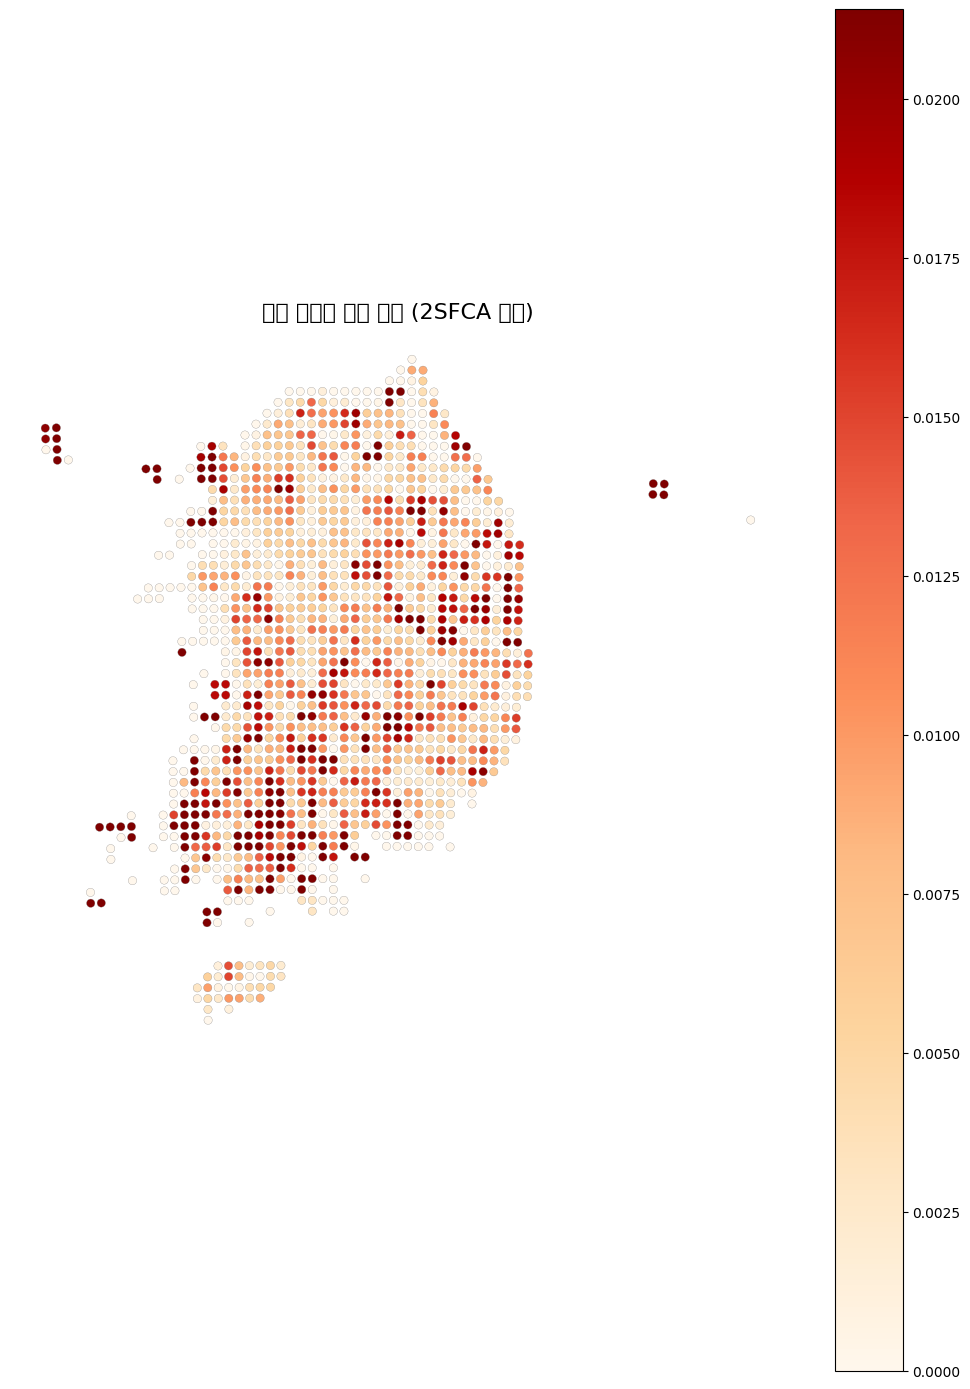

In [19]:
import matplotlib.pyplot as plt
# figure 생성
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

# 이상값 필터링
vmin = gdf_result["Accessibility_Index"].quantile(0.1)
vmax = gdf_result["Accessibility_Index"].quantile(0.9)

# 시각화
gdf_result.plot(
    column="Accessibility_Index",
    cmap="OrRd",
    legend=True,
    edgecolor="gray", linewidth=0.2,
    ax=ax,
    vmin=vmin,
    vmax=vmax
)
##########################
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font.*")
##########################

ax.set_title("의료 접근성 지표 분포 (2SFCA 기반)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

In [37]:
# !apt-get -qq install fonts-nanum
# !fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [39]:
gdf_admin = gpd.read_file("/content/drive/MyDrive/1. 2024년 2분기 기준 시도 경계/bnd_sido_00_2024_2Q.shp")
gdf_admin = gdf_admin.to_crs(epsg=3857)
gdf_admin

,BASE_DATE,SIDO_CD,SIDO_NM,geometry
0,20240630,11,서울특별시,"POLYGON ((14139782.502 4537275.275, 14140040.8..."
1,20240630,21,부산광역시,"MULTIPOLYGON (((14354852.073 4148185.643, 1435..."
2,20240630,23,인천광역시,"MULTIPOLYGON (((14002554.217 4429398.301, 1400..."
3,20240630,22,대구광역시,"POLYGON ((14299594.39 4345694.015, 14299593.70..."
4,20240630,24,광주광역시,"POLYGON ((14110896.107 4199092.666, 14110975.4..."
5,20240630,25,대전광역시,"POLYGON ((14181983.17 4368131.812, 14182114.82..."
6,20240630,26,울산광역시,"MULTIPOLYGON (((14394968.8 4208682.215, 143949..."
7,20240630,31,경기도,"MULTIPOLYGON (((14119434.182 4432081.851, 1411..."
8,20240630,32,강원특별자치도,"MULTIPOLYGON (((14400717.805 4459801.617, 1440..."
9,20240630,33,충청북도,"POLYGON ((14246825.211 4474972.803, 14246877.7..."


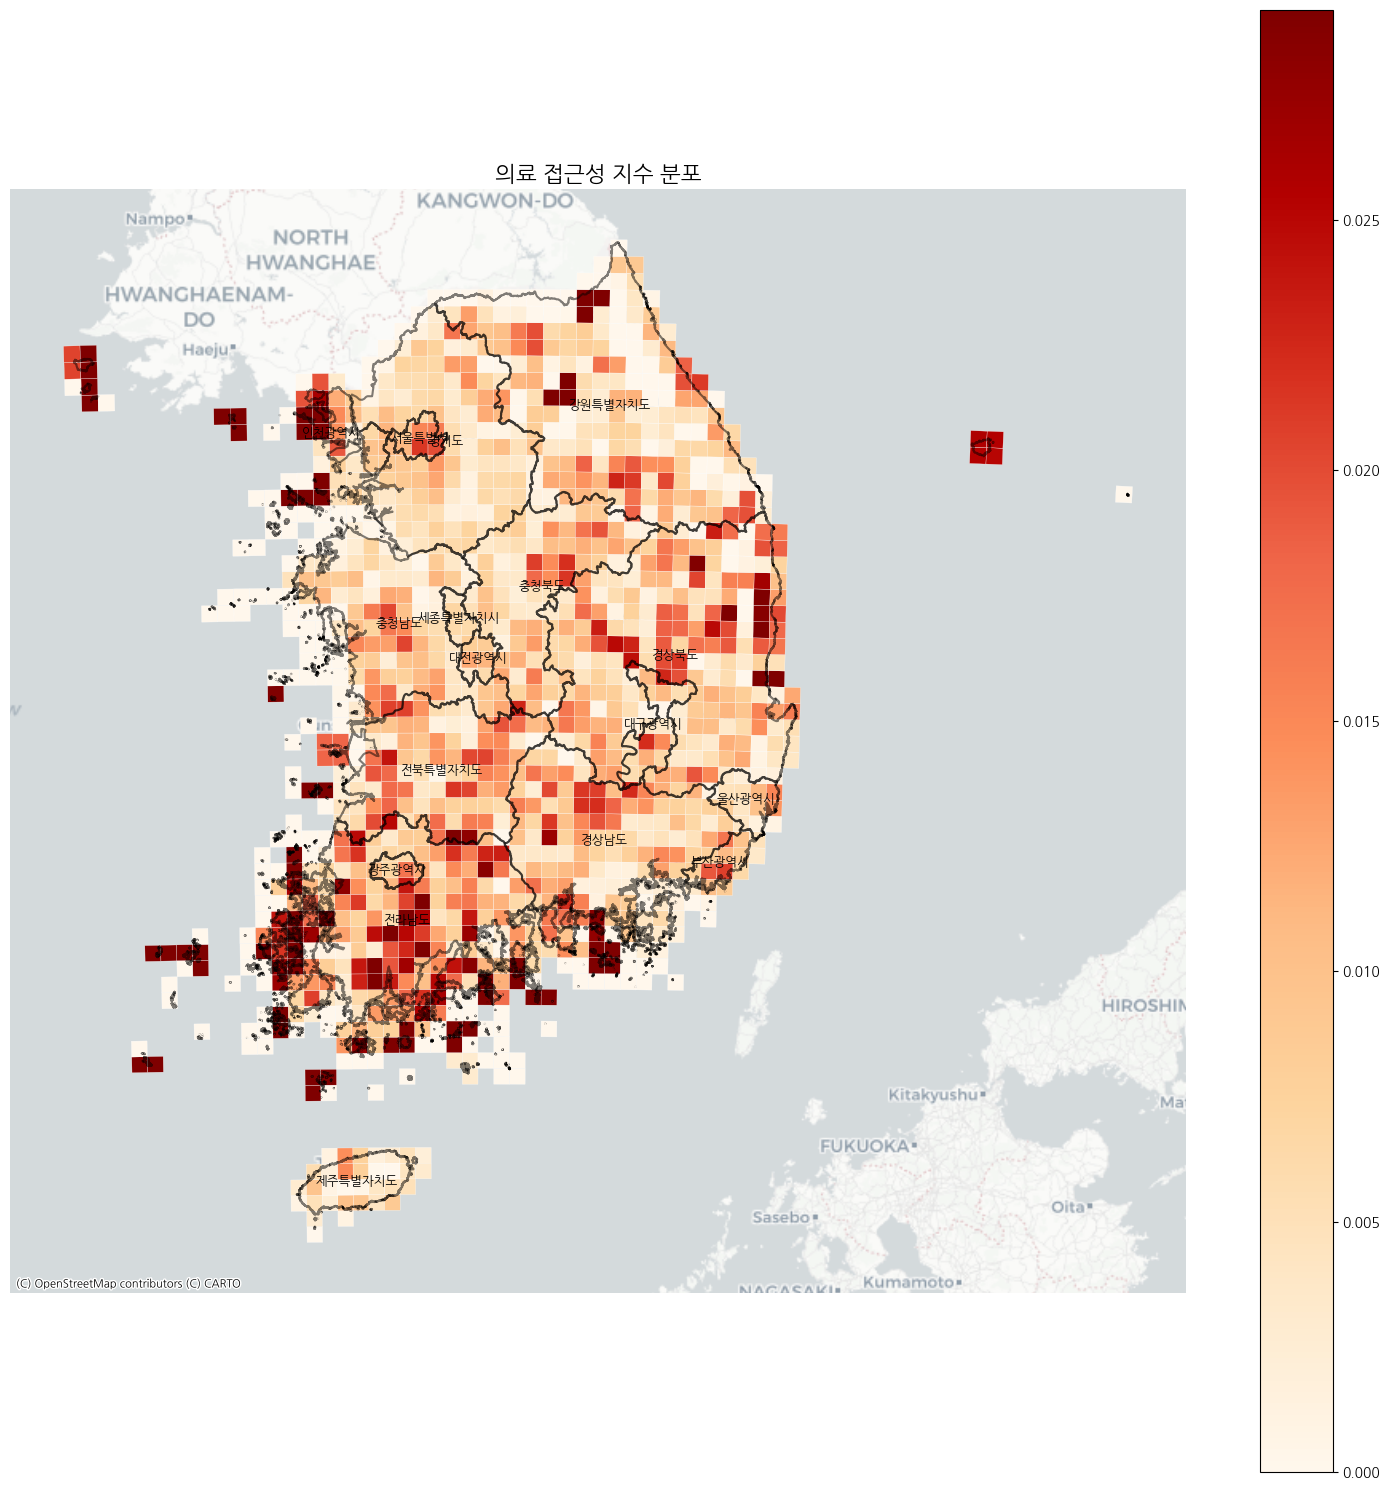

In [42]:
##### 경계 - 시도

import matplotlib.pyplot as plt
from shapely.geometry import box
import contextily as ctx
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import geopandas as gpd



# 1. gdf_result를 미터 단위 좌표계로 변환 (EPSG:5181) -> 정밀한 거리 기반 그리드 생성이 가능.
gdf_result_m = gdf_result.to_crs(epsg=5181)

# 2. 점을 1km x 1km 사각형 폴리곤으로 변환하는 함수
def point_to_grid_polygon(point, size=10000):
    x, y = point.x, point.y
    return box(x - size/2, y - size/2, x + size/2, y + size/2)

# 3. geometry를 폴리곤으로 변환
gdf_result_m['geometry'] = gdf_result_m.geometry.apply(lambda p: point_to_grid_polygon(p, size=10000))

vmin = gdf_result_m['Accessibility_Index'].quantile(0.05)
vmax = gdf_result_m['Accessibility_Index'].quantile(0.95)

# 4. EPSG:3857로 변환(contextily용)
gdf_plot = gdf_result_m.to_crs(epsg=3857)

# 5. 행정구역 경계
gdf_admin = gpd.read_file("/content/drive/MyDrive/1. 2024년 2분기 기준 시도 경계/bnd_sido_00_2024_2Q.shp")
gdf_admin = gdf_admin.to_crs(epsg=3857)

# 6. 시각화
plt.rcParams['font.family'] = 'NanumGothic'
fig, ax = plt.subplots(1, 1, figsize=(15,15))

gdf_plot.plot(
    column='Accessibility_Index',
    cmap='OrRd',
    linewidth=0.2,
    edgecolor='white',
    legend=True,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    alpha=1
)

# 7. 행정구역 경계선 시각화
gdf_admin.boundary.plot(ax=ax, color='black', linewidth=1.5, alpha=0.5)

# 8. 행정구역 이름 라벨 표시 (중심좌표 기준)
for idx,row in gdf_admin.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['SIDO_NM'],fontsize=9,ha='center',va='center',color='black')

# 7. 배경지도 추가
ctx.add_basemap(ax, source="CartoDB.Positron" ,crs=gdf_plot.crs.to_string())

ax.set_title('의료 접근성 지수 분포', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

In [43]:
##### 경계 - 시군구

import matplotlib.pyplot as plt
from shapely.geometry import box
import contextily as ctx
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import geopandas as gpd



# 1. gdf_result를 미터 단위 좌표계로 변환 (EPSG:5181) -> 정밀한 거리 기반 그리드 생성이 가능.
gdf_result_m = gdf_result.to_crs(epsg=5181)

# 2. 점을 1km x 1km 사각형 폴리곤으로 변환하는 함수
def point_to_grid_polygon(point, size=10000):
    x, y = point.x, point.y
    return box(x - size/2, y - size/2, x + size/2, y + size/2)

# 3. geometry를 폴리곤으로 변환
gdf_result_m['geometry'] = gdf_result_m.geometry.apply(lambda p: point_to_grid_polygon(p, size=10000))

vmin = gdf_result_m['Accessibility_Index'].quantile(0.05)
vmax = gdf_result_m['Accessibility_Index'].quantile(0.95)

# 4. EPSG:3857로 변환(contextily용)
gdf_plot = gdf_result_m.to_crs(epsg=3857)

# 5. 행정구역 경계
gdf_admin = gpd.read_file("/content/drive/MyDrive/bnd_dong_00_2024_2Q/bnd_dong_00_2024_2Q.shp")
gdf_admin = gdf_admin.to_crs(epsg=3857)

# 6. 시각화
plt.rcParams['font.family'] = 'NanumGothic'
fig, ax = plt.subplots(1, 1, figsize=(25, 20))

gdf_plot.plot(
    column='Accessibility_Index',
    cmap='OrRd',
    linewidth=0.2,
    edgecolor='white',
    legend=True,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    alpha=1
)

# 7. 행정구역 경계선 시각화
gdf_admin.boundary.plot(ax=ax, color='white', linewidth=1.5, alpha=0.5)

# 8. 행정구역 이름 라벨 표시 (중심좌표 기준)
for idx,row in gdf_admin.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['ADM_NM'],fontsize=6,ha='center',va='center',color='black')

# 7. 배경지도 추가
ctx.add_basemap(ax, source="CartoDB.Positron" ,crs=gdf_plot.crs.to_string())

ax.set_title('의료 접근성 지수 분포', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

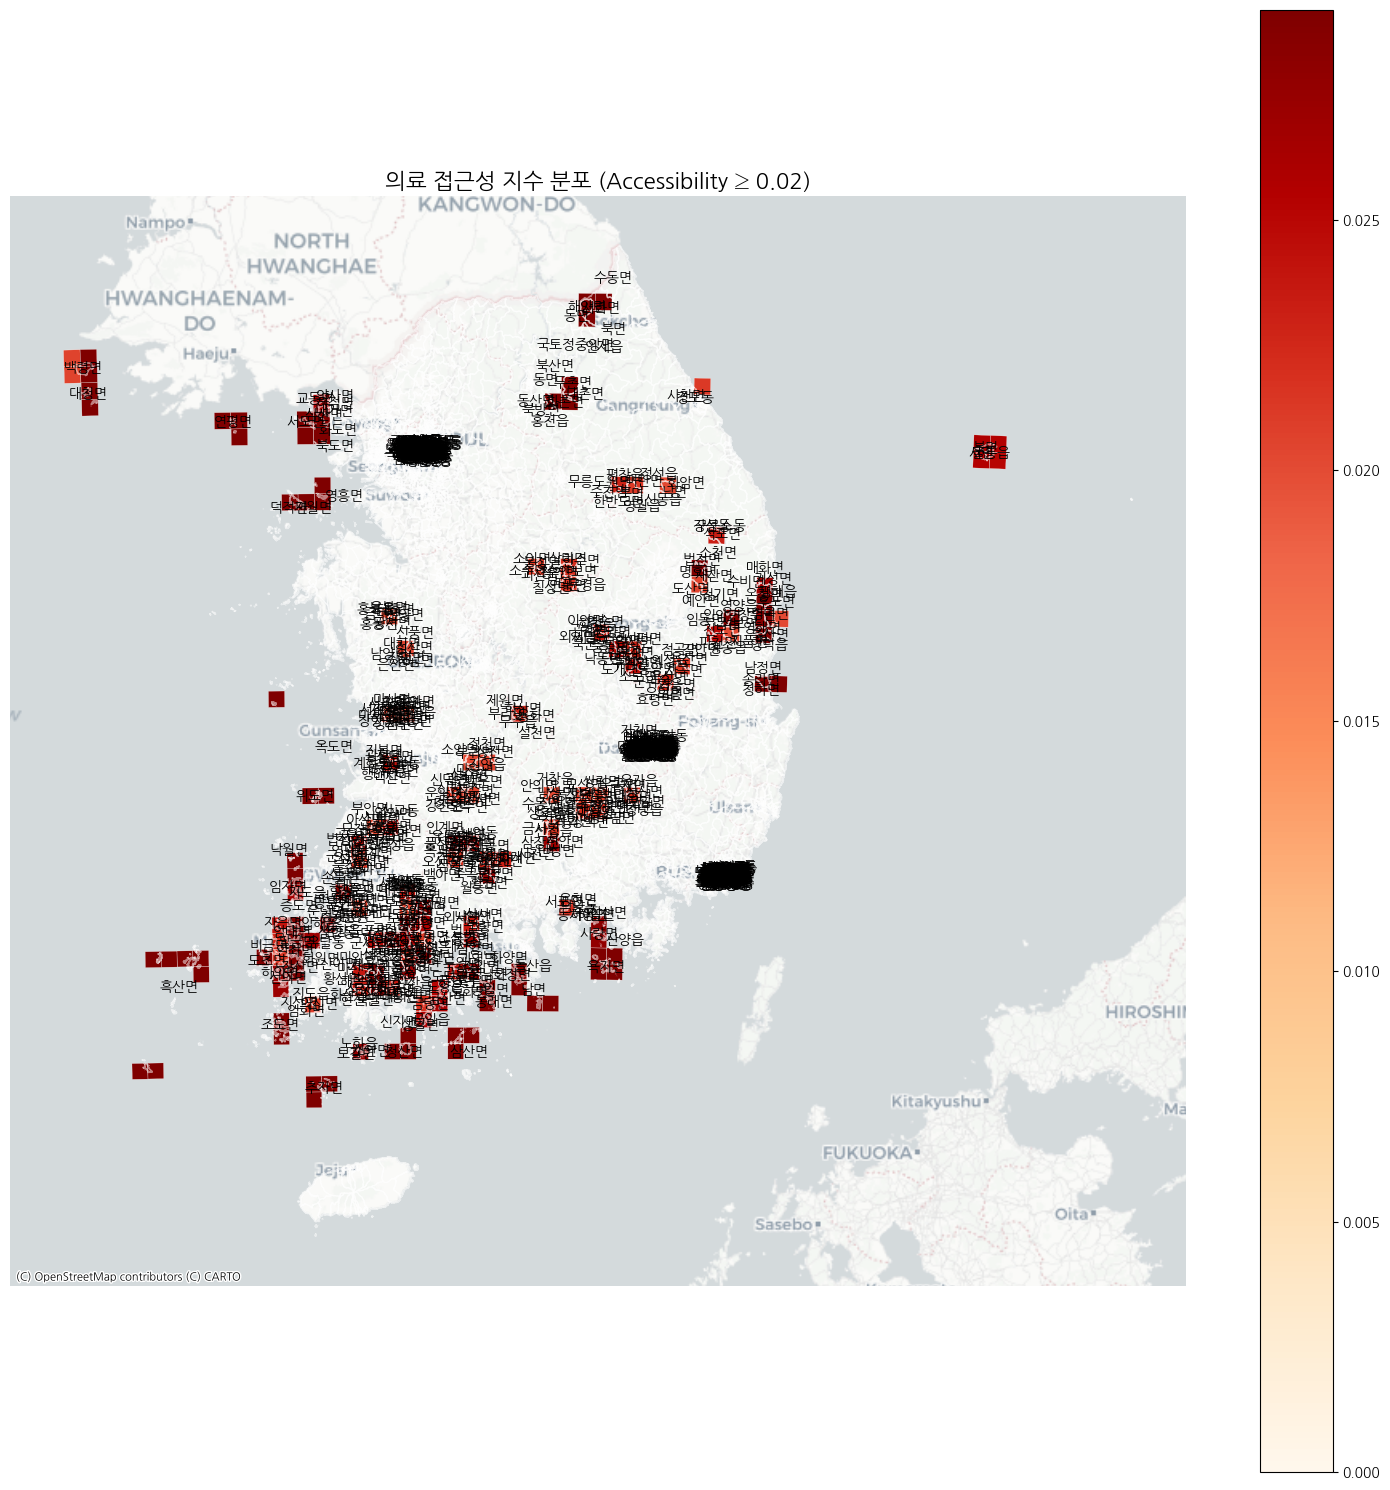

In [46]:
import matplotlib.pyplot as plt
from shapely.geometry import box
import contextily as ctx
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import geopandas as gpd



# 1. gdf_result를 미터 단위 좌표계로 변환 (EPSG:5181) -> 정밀한 거리 기반 그리드 생성이 가능.
gdf_result_m = gdf_result.to_crs(epsg=5181)

# 2. 점을 1km x 1km 사각형 폴리곤으로 변환하는 함수
def point_to_grid_polygon(point, size=10000):
    x, y = point.x, point.y
    return box(x - size/2, y - size/2, x + size/2, y + size/2)

# 3. geometry를 폴리곤으로 변환
gdf_result_m['geometry'] = gdf_result_m.geometry.apply(lambda p: point_to_grid_polygon(p, size=10000))

vmin = gdf_result_m['Accessibility_Index'].quantile(0.05)
vmax = gdf_result_m['Accessibility_Index'].quantile(0.95)

# 4. EPSG:3857로 변환(contextily용)
gdf_plot = gdf_result_m.to_crs(epsg=3857)

# 5. EPSG:3857로 변환
gdf_plot = gdf_result_m.to_crs(epsg=3857)

# 6. 행정구역 shp load / CRS 변환
gdf_admin = gpd.read_file("/content/drive/MyDrive/bnd_dong_00_2024_2Q/bnd_dong_00_2024_2Q.shp").to_crs(epsg=3857)

# 7. 필터링: 접근성 지수 ≥ 0.02인 격자만
gdf_plot_filtered = gdf_plot[gdf_plot['Accessibility_Index'] >= 0.02]

# 8. 시각화 시작
plt.rcParams['font.family'] = 'NanumGothic'
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

gdf_plot_filtered.plot(
    column='Accessibility_Index', cmap='OrRd', linewidth=0.2,
    edgecolor='white', legend=True, ax=ax, vmin=vmin, vmax=vmax, alpha=1
)

gdf_admin.boundary.plot(ax=ax, color='white', linewidth=1.0, alpha=0.5)

# 9. 행정구역 라벨 조건부 표시
# 교집합 계산
gdf_intersect = gpd.overlay(gdf_admin, gdf_plot_filtered, how='intersection')
adm_codes = gdf_intersect['ADM_CD'].unique()
gdf_admin_for_label = gdf_admin[gdf_admin['ADM_CD'].isin(adm_codes)]

for idx, row in gdf_admin_for_label.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['ADM_NM'], fontsize=10, ha='center', va='center', color='black')

# 10. 배경지도 추가
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf_plot.crs.to_string())

ax.set_title('의료 접근성 지수 분포 (Accessibility ≥ 0.02)', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()
